# Optimal Weights of Random Portfolio
-----
#### John E. Llenarez
-----
**Introduction**

This project aims to construct an optimal investment portfolio using a set of technology stocks, including Apple, Google, Microsoft, Qualcomm, Micron, Samsung, Xiaomi, and TSMC. The analysis combines statistical modeling and financial theory to estimate expected returns, model volatility, and quantify risk.

The workflow integrates multiple techniques: time series modeling using ARIMA for return forecasting, GARCH for volatility estimation, portfolio optimization using mean-variance theory, and Monte Carlo simulation for Value at Risk (VaR) estimation. The goal is to develop a data-driven framework for portfolio allocation and risk assessment.

###Library

In [ ]:
!pip install arch
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.6 MB/s eta 0:00:00


In [ ]:
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import yfinance as yfin
from scipy.optimize import minimize
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model
from pmdarima.arima import auto_arima

### Data Importation

Stocks
- Samsung (Korea), Xiaomi (Hong Kong), Apple, AMD, Amazon, Google, Intel, Meta, Microsoft, Micron, Nvidia,Oracle, Qualcomm, TSMC (Taiwan)

Exchange Rate
- Korean Won, Taiwan Dollar, Hong Kong Dollar


In [ ]:
start = datetime.date(2020, 1, 1)
today = datetime.date.today()
yesterday = (today - datetime.timedelta(days=1)).strftime('%Y-%m-%d')
end = yesterday

stocks = yfin.download(["1810.HK", "AAPL", "005930.KS", "2330.TW",
                        "GOOGL", "MSFT", "QCOM", "MU", "TWDUSD=X", "KRWUSD=X", "HKDUSD=X"], start, end, auto_adjust = False)["Adj Close"]
stocks.head()

[*********************100%***********************]  11 of 11 completed


Ticker,005930.KS,1810.HK,2330.TW,AAPL,GOOGL,HKDUSD=X,KRWUSD=X,MSFT,MU,QCOM,TWDUSD=X
Date,,,,,,,,,,,
2020-01-01,NaN,NaN,NaN,NaN,NaN,0.128427,0.000867,NaN,NaN,NaN,0.033447
2020-01-02,47470.906250,11.22,299.373993,72.400536,67.873009,0.128329,0.000867,152.158386,54.021149,77.151039,0.033508
2020-01-03,47728.906250,10.90,299.815491,71.696640,67.517960,0.128398,0.000864,150.263794,53.182400,75.698296,0.033445
2020-01-06,47728.906250,10.98,293.192200,72.267929,69.317589,0.128510,0.000858,150.652161,52.246132,75.254677,0.033294
2020-01-07,47986.878906,11.00,290.984436,71.928055,69.183701,0.128694,0.000857,149.278564,56.829990,77.394608,0.033281


#### Converting to USD

In [ ]:
stocks_filled = stocks.ffill()

stocks_filled['SMSNG_USD'] = stocks_filled['005930.KS'] * stocks_filled['KRWUSD=X']
stocks_filled['XIAO_USD']  = stocks_filled['1810.HK']   * stocks_filled['HKDUSD=X']
stocks_filled['TSMC_USD']  = stocks_filled['2330.TW']   * stocks_filled['TWDUSD=X']

final_cols = ["AAPL", "GOOGL", "MSFT", "QCOM", "MU",
              "SMSNG_USD", "XIAO_USD", "TSMC_USD"]

asian_usd_cols = ['SMSNG_USD', 'XIAO_USD', 'TSMC_USD']


stocks_final = stocks_filled[final_cols].dropna()

print(stocks_final.isnull().sum())
display(stocks_final.head())

Ticker
AAPL         0
GOOGL        0
MSFT         0
QCOM         0
MU           0
SMSNG_USD    0
XIAO_USD     0
TSMC_USD     0
dtype: int64


Ticker,AAPL,GOOGL,MSFT,QCOM,MU,SMSNG_USD,XIAO_USD,TSMC_USD
Date,,,,,,,,
2020-01-02,72.400536,67.873009,152.158386,77.151039,54.021149,41.137037,1.439846,10.031296
2020-01-03,71.696640,67.517960,150.263794,75.698296,53.182400,41.246949,1.399535,10.027275
2020-01-06,72.267929,69.317589,150.652161,75.254677,52.246132,40.939150,1.411039,9.761685
2020-01-07,71.928055,69.183701,149.278564,77.394608,56.829990,41.105066,1.415629,9.684309
2020-01-08,73.085098,69.676125,151.656311,77.168427,56.098515,41.876164,1.424659,9.704334


In [ ]:
stocks_final = stocks_final.rename(columns={
    "XIAO_USD": "Xiaomi_USD",
    "AAPL": "Apple",
    "SMSNG_USD": "Samsung_USD",
    "GOOGL": "Google",
    "QCOM": "Qualcomm",
    "MU": "Micron",
    "MSFT": "Microsoft"
})
display(stocks_final.head())

Ticker,Apple,Google,Microsoft,Qualcomm,Micron,Samsung_USD,Xiaomi_USD,TSMC_USD
Date,,,,,,,,
2020-01-02,72.400536,67.873009,152.158386,77.151039,54.021149,41.137037,1.439846,10.031296
2020-01-03,71.696640,67.517960,150.263794,75.698296,53.182400,41.246949,1.399535,10.027275
2020-01-06,72.267929,69.317589,150.652161,75.254677,52.246132,40.939150,1.411039,9.761685
2020-01-07,71.928055,69.183701,149.278564,77.394608,56.829990,41.105066,1.415629,9.684309
2020-01-08,73.085098,69.676125,151.656311,77.168427,56.098515,41.876164,1.424659,9.704334


## Data Preparation

The dataset consists of historical daily stock prices. To make the data suitable for financial modeling, prices are transformed into **log returns**.

Log returns are preferred because they stabilize variance, allow for easier aggregation over time, and are more consistent with financial theory.

#### Log Return Transformation

In [ ]:
asset_returns_stocks = pd.DataFrame(index=stocks_final.index)

for stock_name in stocks_final.columns:
    asset_returns_stocks[f"{stock_name}_asset_return"] = np.log(stocks_final[stock_name] / stocks_final[stock_name].shift(1))
asset_returns_stocks = asset_returns_stocks.dropna()
display(asset_returns_stocks.head())

,Apple_asset_return,Google_asset_return,Microsoft_asset_return,Qualcomm_asset_return,Micron_asset_return,Samsung_USD_asset_return,Xiaomi_USD_asset_return,TSMC_USD_asset_return
Date,,,,,,,,
2020-01-03,-0.009770,-0.005245,-0.012530,-0.019009,-0.015648,0.002668,-0.028396,-0.000401
2020-01-06,0.007937,0.026305,0.002581,-0.005878,-0.017762,-0.007490,0.008186,-0.026844
2020-01-07,-0.004714,-0.001933,-0.009159,0.028039,0.084098,0.004045,0.003247,-0.007958
2020-01-08,0.015958,0.007092,0.015803,-0.002927,-0.012955,0.018585,0.006359,0.002066
2020-01-09,0.021019,0.010443,0.012416,0.013437,-0.003657,0.035666,0.037347,0.023156


#### Simple Plot (Raw vs Asset Return)

In [ ]:
stocks_final.columns #Ignore just for copy paste

Index(['Apple', 'Google', 'Microsoft', 'Qualcomm', 'Micron', 'Samsung_USD',
       'Xiaomi_USD', 'TSMC_USD'],
      dtype='object', name='Ticker')

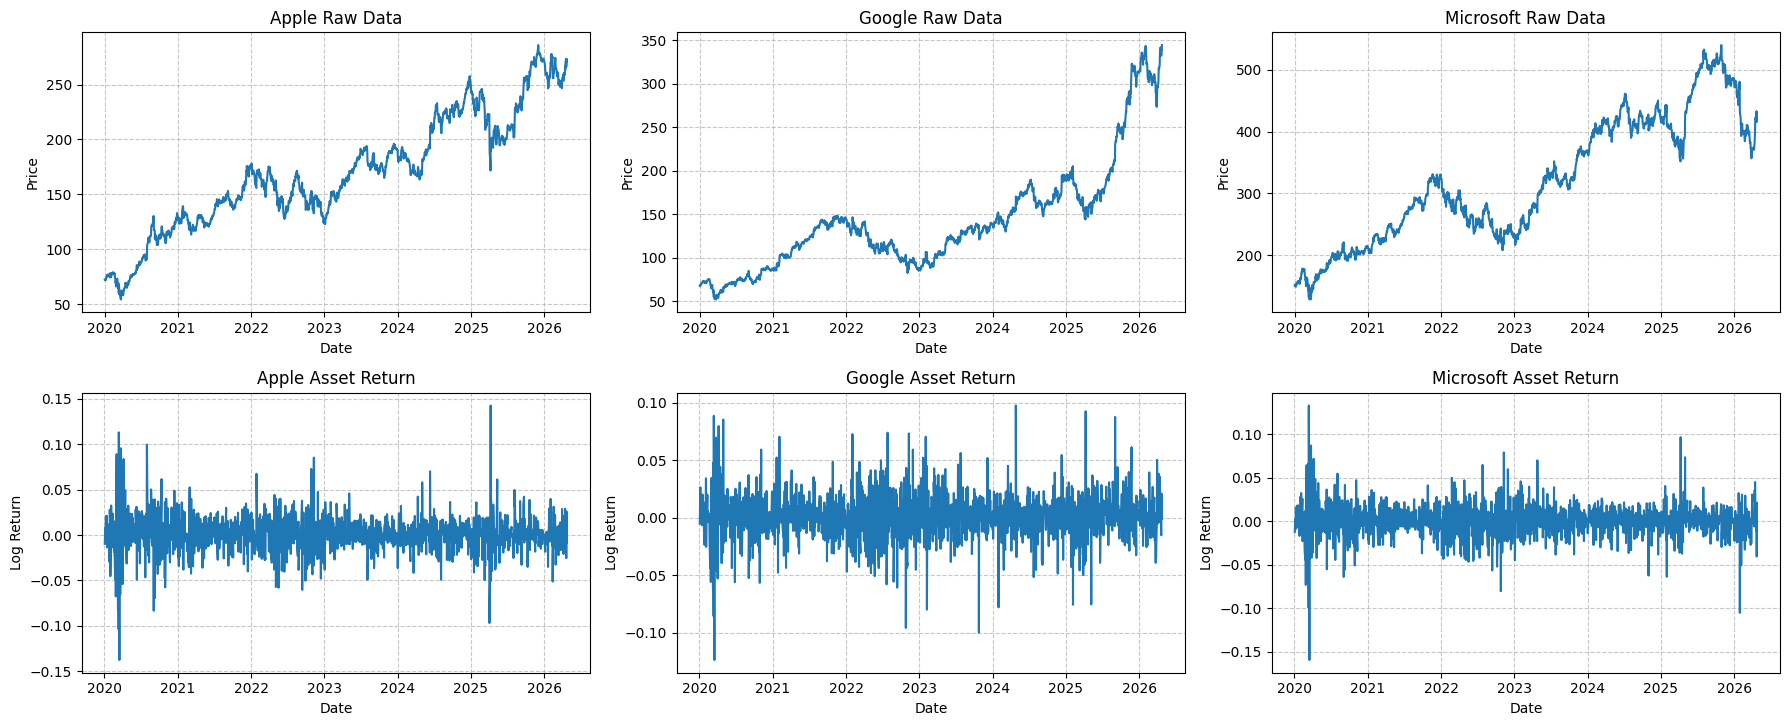

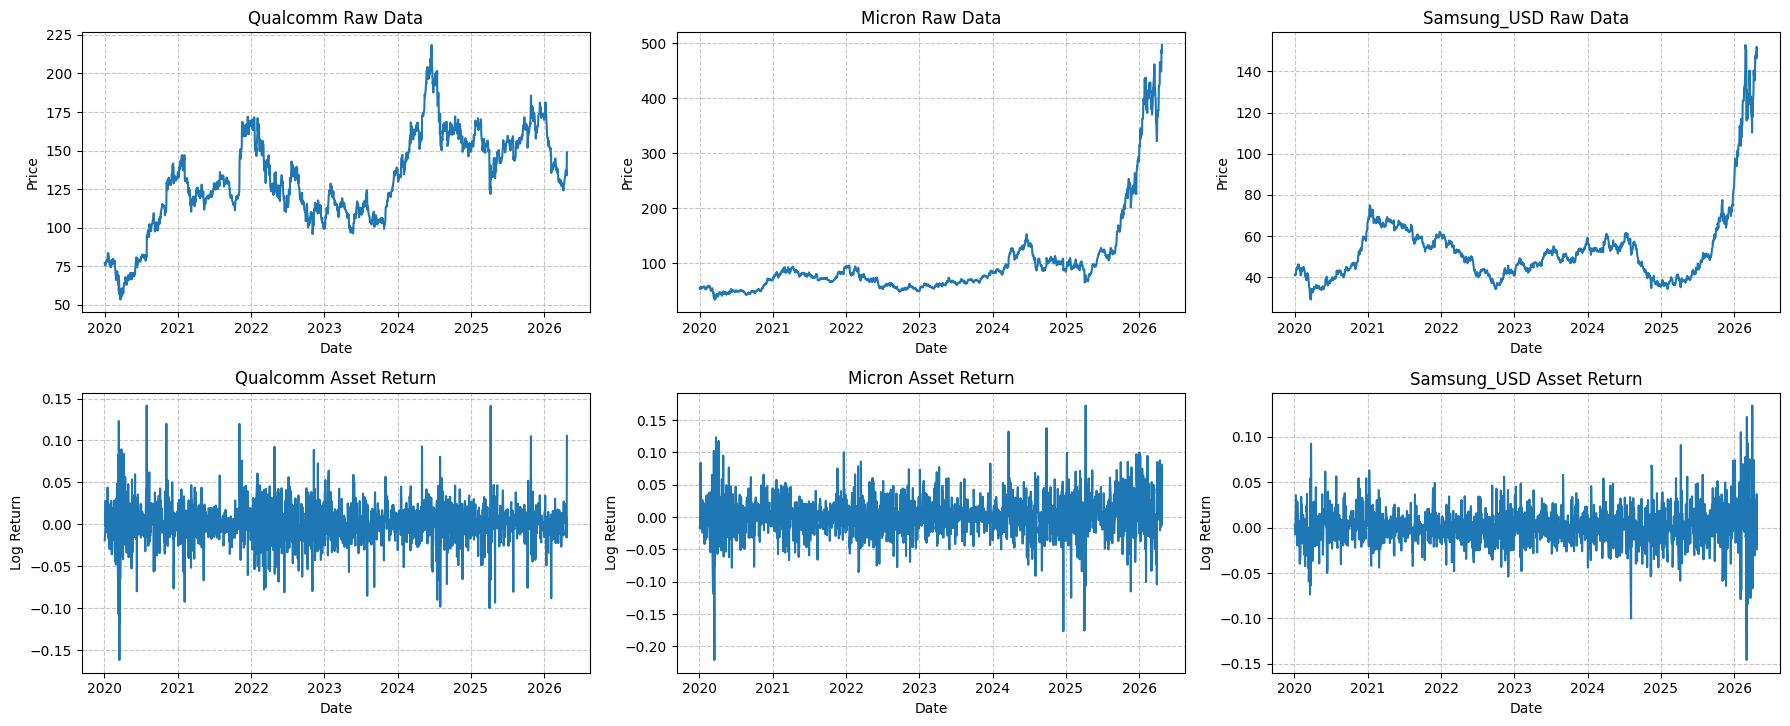

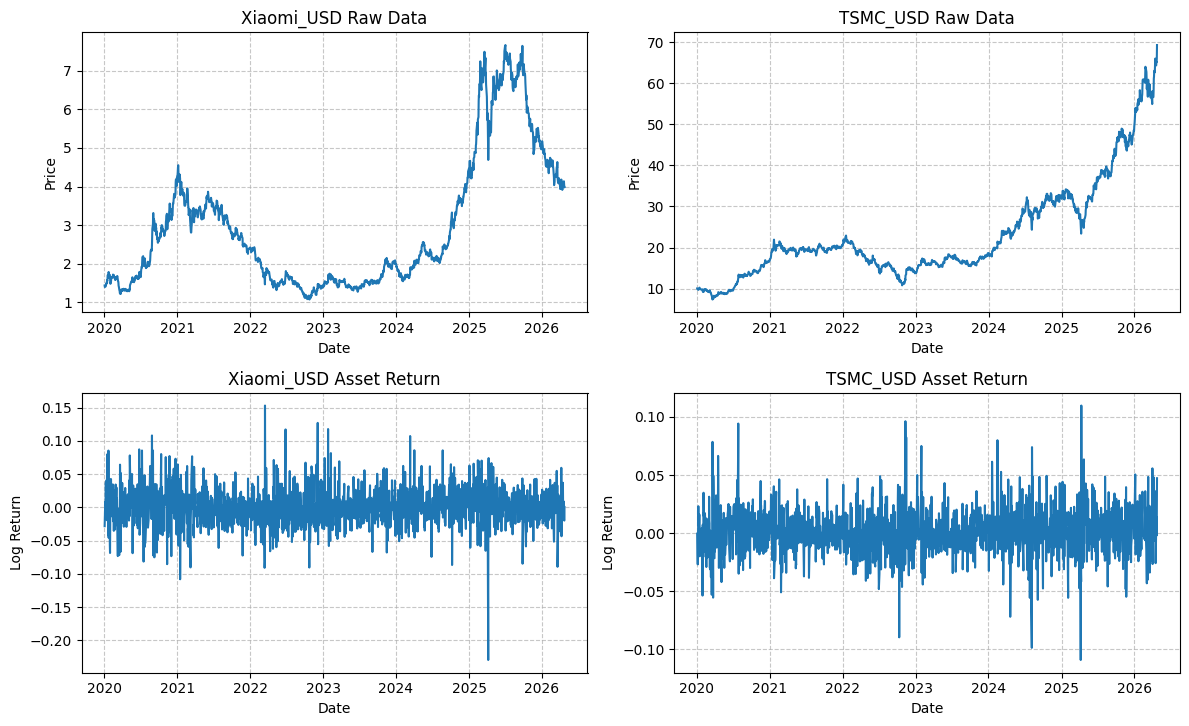

In [ ]:
stocks_to_plot = ['Apple', 'Google', 'Microsoft', 'Qualcomm', 'Micron', 'Samsung_USD',
       'Xiaomi_USD', 'TSMC_USD']

chunk_size = 3

for k in range(0, len(stocks_to_plot), chunk_size):
    current_chunk = stocks_to_plot[k:k + chunk_size]
    num_stocks_in_chunk = len(current_chunk)

    num_cols_in_figure = min(num_stocks_in_chunk, chunk_size)
    num_rows_in_figure = 2

    fig, axes = plt.subplots(num_rows_in_figure, num_cols_in_figure, figsize=(num_cols_in_figure * 6, num_rows_in_figure * 4))

    for j, stock in enumerate(current_chunk):
        if num_cols_in_figure == 1:
            ax_raw = axes[0]
            ax_returns = axes[1]
        else:
            ax_raw = axes[0, j]
            ax_returns = axes[1, j]


        ax_raw.plot(stocks_final[stock])
        ax_raw.set_title(f"{stock} Raw Data")
        ax_raw.set_xlabel("Date")
        ax_raw.set_ylabel("Price")
        ax_raw.grid(True, linestyle="--", alpha=0.7)


        ax_returns.plot(asset_returns_stocks[f"{stock}_asset_return"])
        ax_returns.set_title(f"{stock} Asset Return")
        ax_returns.set_xlabel("Date")
        ax_returns.set_ylabel("Log Return")
        ax_returns.grid(True, linestyle="--", alpha=0.7)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f"Asset_Returns_Batch_{k // chunk_size + 1}.png")
    plt.show()

## Initial Observations

From the plots, raw prices show strong trends and non-stationary behavior, while log returns fluctuate around a constant mean.

This transformation is essential, as most financial models assume stationarity.

#### Trading days

In [ ]:
num_trading_days = len(stocks_final)
start_date = stocks_final.index.min()
end_date = stocks_final.index.max()


time_span_years = (end_date - start_date).days / 365.25


average_trading_days_per_year = num_trading_days / time_span_years

print(f"Total trading days: {num_trading_days}")
print(f"Data starts: {start_date.strftime('%Y-%m-%d')}")
print(f"Data ends: {end_date.strftime('%Y-%m-%d')}")
print(f"Approximate time span in years: {time_span_years:.2f}")
print(f"Average trading days per year: {average_trading_days_per_year:.2f}")

Total trading days: 1644
Data starts: 2020-01-02
Data ends: 2026-04-24
Approximate time span in years: 6.31
Average trading days per year: 260.62


#### Optimal Weights of the Portfolio

In [ ]:
cov_matrix = asset_returns_stocks.cov() * average_trading_days_per_year
corr_matrix = asset_returns_stocks.corr()
volatility = asset_returns_stocks.std() * np.sqrt(average_trading_days_per_year)
mu = asset_returns_stocks.mean() * average_trading_days_per_year
sigma = asset_returns_stocks.cov() * average_trading_days_per_year

In [ ]:
def portfolio_variance(weights, cov_matrix):
    return np.dot(weights.T, np.dot(cov_matrix, weights))

# 2. Initial weight (Equal weight)
num_assets = len(asset_returns_stocks.columns)
init_weights = np.array([1/num_assets] * num_assets)

# 3. Constraints: Weights must sum to 1
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})


bounds = tuple((0, 1) for _ in range(num_assets))

optimal_result = minimize(portfolio_variance, init_weights,
                          args=(cov_matrix,),
                          method='SLSQP',
                          bounds=bounds,
                          constraints=constraints)

optimal_weights = optimal_result.x

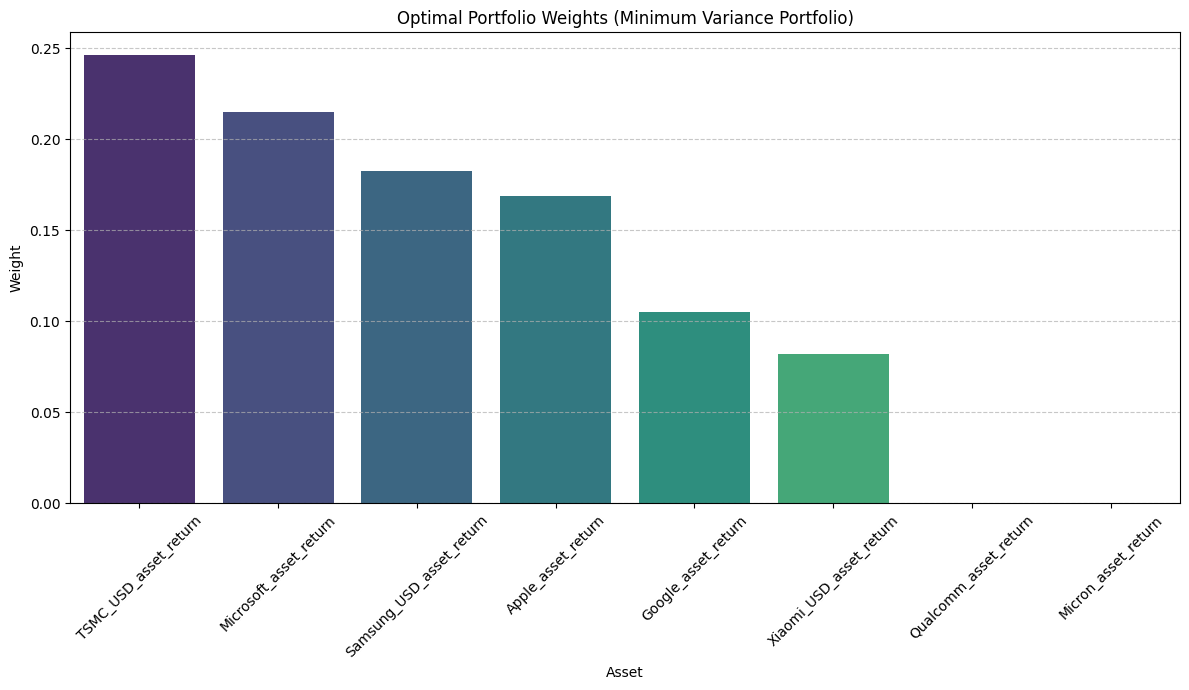

In [ ]:
optimal_weights_series = pd.Series(optimal_weights, index=asset_returns_stocks.columns)
optimal_weights_series = optimal_weights_series.sort_values(ascending=False)

fig = plt.figure(figsize=(12, 7))
sns.barplot(x=optimal_weights_series.index, y=optimal_weights_series.values, hue=optimal_weights_series.index, palette="viridis", legend=False)
plt.title("Optimal Portfolio Weights (Minimum Variance Portfolio)")
plt.xlabel("Asset")
plt.ylabel("Weight")
plt.xticks(rotation=90)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The bar chart above shows the optimal weights for each asset in the minimum variance portfolio. Assets with higher bars represent a larger proportion in the optimized portfolio.

In [ ]:
expected_returns = asset_returns_stocks.mean() * average_trading_days_per_year
portfolio_return_ew = expected_returns.mean()

optimal_return = np.dot(optimal_weights, mu)


print(f"Equal-Weighted Portfolio Return: {portfolio_return_ew:.2%}")
print(f"Optimal Portfolio Return: {optimal_return:.2%}")

Equal-Weighted Portfolio Return: 21.97%
Optimal Portfolio Return: 22.34%


Now, we'll define the functions for portfolio return and risk, and then iterate through a range of target returns to build the efficient frontier.

In [ ]:
def portfolio_return(weights, expected_returns):
    return np.dot(weights, expected_returns)

min_asset_return = expected_returns.min()
max_asset_return = expected_returns.max()

target_returns = np.linspace(min_asset_return * 0.8, max_asset_return * 1.2, 50)

portfolio_volatilities = []
portfolio_returns = []
all_weights = []

num_assets = len(asset_returns_stocks.columns)

current_weights = np.array([1/num_assets] * num_assets)

for target_r in target_returns:
    constraints_ef = (
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
        {'type': 'eq', 'fun': lambda x: portfolio_return(x, expected_returns) - target_r}
    )

    result = minimize(portfolio_variance,
                      current_weights,
                      args=(cov_matrix,),
                      method="SLSQP",
                      bounds=bounds,
                      constraints=constraints_ef)

    if result.success:
        current_weights = result.x
        portfolio_volatilities.append(np.sqrt(portfolio_variance(result.x, cov_matrix)))
        portfolio_returns.append(target_r)
        all_weights.append(result.x)

efficient_frontier = pd.DataFrame({
    "Return": portfolio_returns,
    "Volatility": portfolio_volatilities
}, index=portfolio_returns)

optimal_weights_df = pd.DataFrame(all_weights, columns=asset_returns_stocks.columns, index=portfolio_returns)

display(efficient_frontier.head())
display(optimal_weights_df.head())

,Return,Volatility
0.111063,0.111063,0.369712
0.117980,0.117980,0.341501
0.124896,0.124896,0.316826
0.131813,0.131813,0.293860
0.138730,0.138730,0.272910


,Apple_asset_return,Google_asset_return,Microsoft_asset_return,Qualcomm_asset_return,Micron_asset_return,Samsung_USD_asset_return,Xiaomi_USD_asset_return,TSMC_USD_asset_return
0.111063,1.211786e-16,0.000000e+00,0.000000,0.880745,0.000000e+00,0.000000,0.119255,5.652965e-18
0.117980,3.679835e-17,7.497402e-17,0.049513,0.760959,7.428616e-17,0.000000,0.189528,0.000000e+00
0.124896,2.568243e-17,0.000000e+00,0.121174,0.662495,8.130433e-17,0.028298,0.188033,0.000000e+00
0.131813,5.156285e-17,0.000000e+00,0.169372,0.576695,5.099283e-17,0.074601,0.179332,0.000000e+00
0.138730,0.000000e+00,2.217505e-17,0.218892,0.490812,8.738792e-18,0.120748,0.169548,6.653705e-18


The tables above show the calculated points on the efficient frontier (Return vs. Volatility) and the corresponding optimal weights for each target return. Now, let's visualize these results.

In [ ]:
def get_portfolio_stats(weights, expected_returns, cov_matrix):
  port_ret = np.dot(weights, expected_returns)
  port_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
  return port_ret, port_std

def negative_sharpe_ratio(weights, expected_returns, cov_matrix, risk_free_rate=0.02):
  port_ret, port_std = get_portfolio_stats(weights, expected_returns, cov_matrix)
  sharpe_ratio = (port_ret - risk_free_rate) / port_std
  return -sharpe_ratio


if negative_sharpe_ratio(optimal_weights, mu, sigma) >= 0:
  print("not efficient")
elif negative_sharpe_ratio(optimal_weights, mu, sigma) < 0:
  print(f"Sharpe Ratio : { round(-negative_sharpe_ratio(optimal_weights, mu, sigma), 4)}")
  print("Conclusion: efficient")

Sharpe Ratio : 1.0204
Conclusion: efficient


In [ ]:
risk_free_rate = 0.02 # Assuming a risk-free rate of 2%

efficient_frontier['Sharpe'] = (efficient_frontier['Return'] - risk_free_rate) / efficient_frontier['Volatility']

best_port = efficient_frontier.loc[efficient_frontier['Sharpe'].idxmax()]


min_volatility_idx = efficient_frontier['Volatility'].idxmin()
min_volatility_portfolio = efficient_frontier.loc[min_volatility_idx]

print(f"Optimal Return (Max Sharpe): {best_port['Return']:.2%}")
print(f"Optimal Volatility (Max Sharpe): {best_port['Volatility']:.2%}")

print(f"\nMinimum Variance Portfolio Return: {min_volatility_portfolio['Return']:.2%}")
print(f"Minimum Variance Portfolio Volatility: {min_volatility_portfolio['Volatility']:.2%}")

Optimal Return (Max Sharpe): 28.40%
Optimal Volatility (Max Sharpe): 22.50%

Minimum Variance Portfolio Return: 22.17%
Minimum Variance Portfolio Volatility: 19.93%


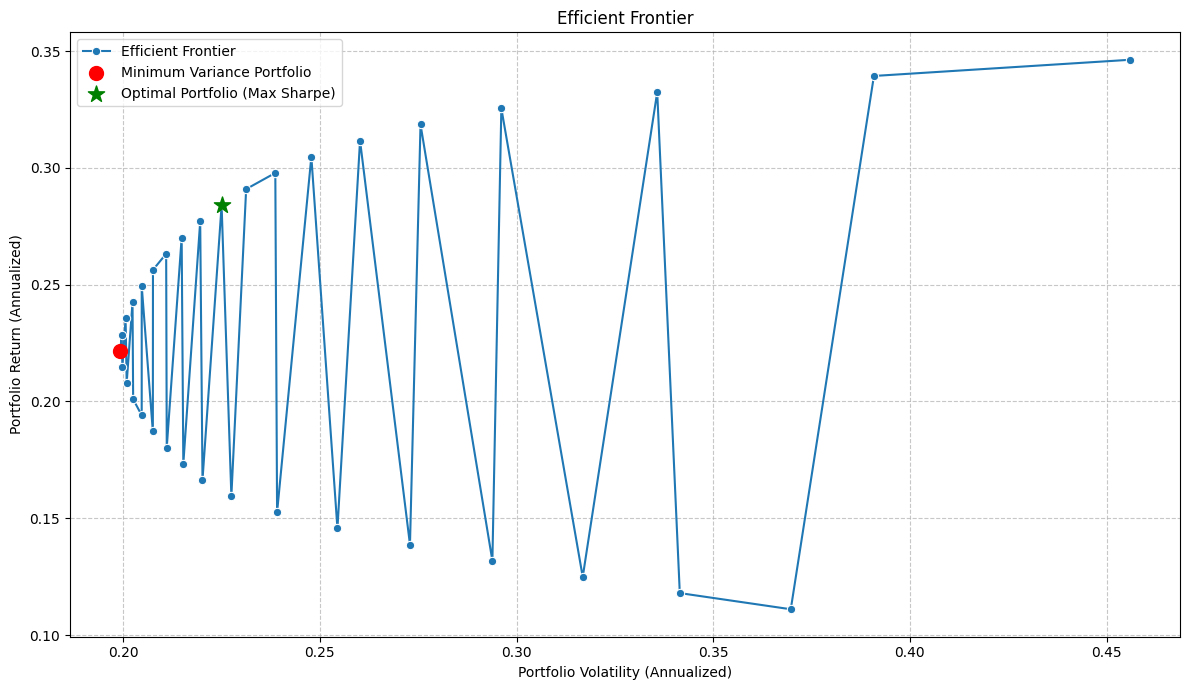

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))
sns.lineplot(x='Volatility', y='Return', data=efficient_frontier, marker='o', ax=ax, label='Efficient Frontier')

ax.scatter(min_volatility_portfolio['Volatility'], min_volatility_portfolio['Return'],
           color='red', s=100, zorder=5, label='Minimum Variance Portfolio')


ax.scatter(best_port['Volatility'], best_port['Return'],
           color='green', s=150, marker='*', zorder=5, label='Optimal Portfolio (Max Sharpe)')

plt.title('Efficient Frontier')
plt.xlabel('Portfolio Volatility (Annualized)')
plt.ylabel('Portfolio Return (Annualized)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

This plot shows the efficient frontier, representing the set of optimal portfolios that offer the highest expected return for a given level of risk (volatility), or the lowest risk for a given expected return. The red dot highlights the minimum variance portfolio.

#### Analyzing Distribution of All Asset Returns (Histograms, Q-Q Plots, Jarque-Bera Test)

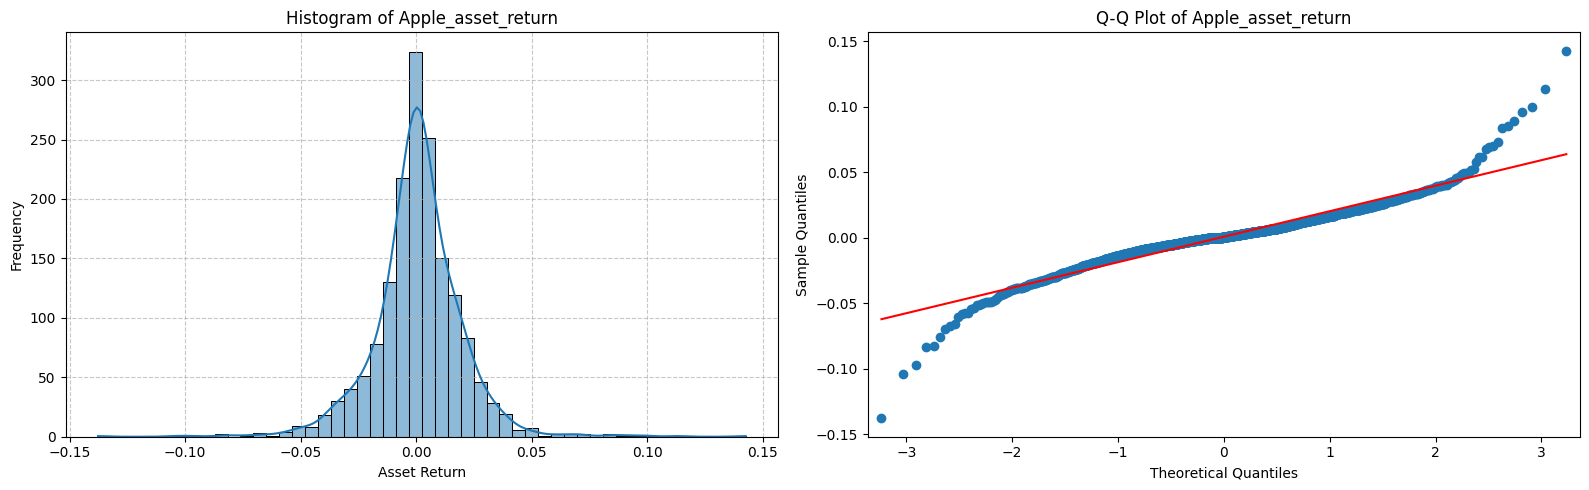

Jarque-Bera Test p-value for Apple_asset_return: 0.0000



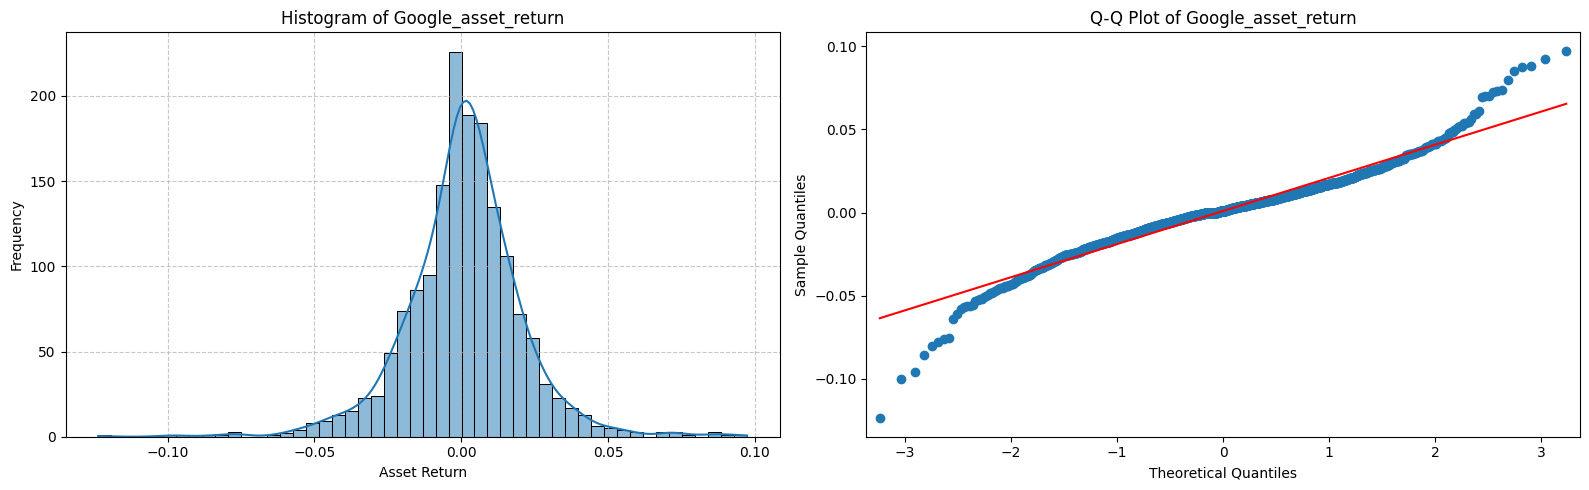

Jarque-Bera Test p-value for Google_asset_return: 0.0000



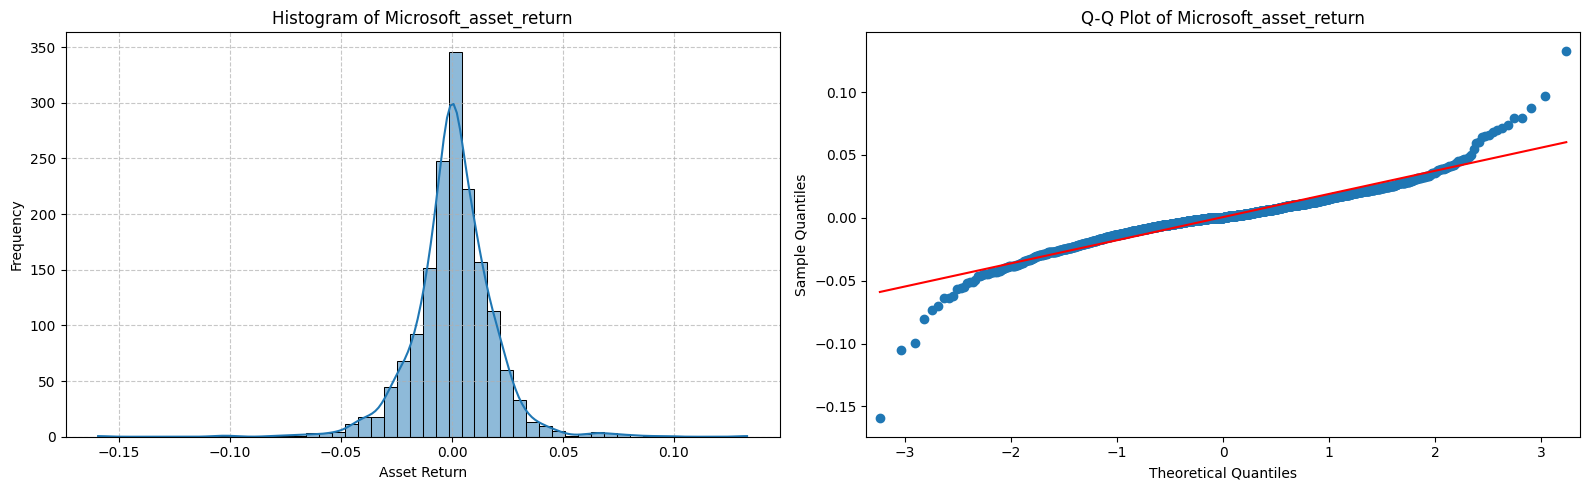

Jarque-Bera Test p-value for Microsoft_asset_return: 0.0000



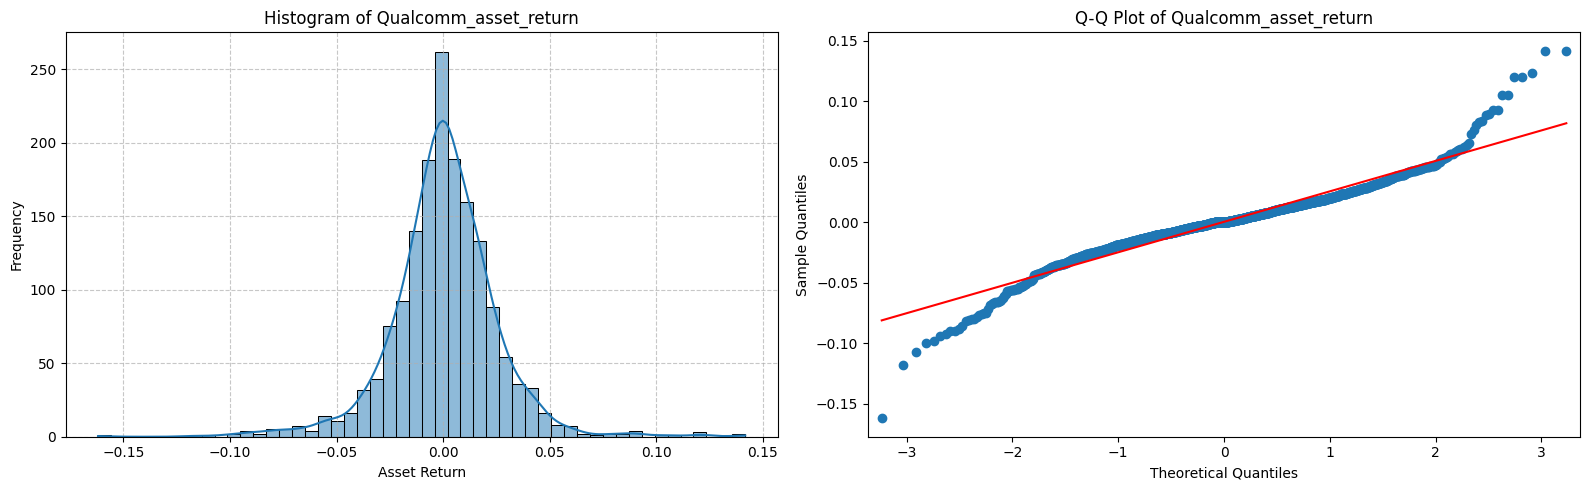

Jarque-Bera Test p-value for Qualcomm_asset_return: 0.0000



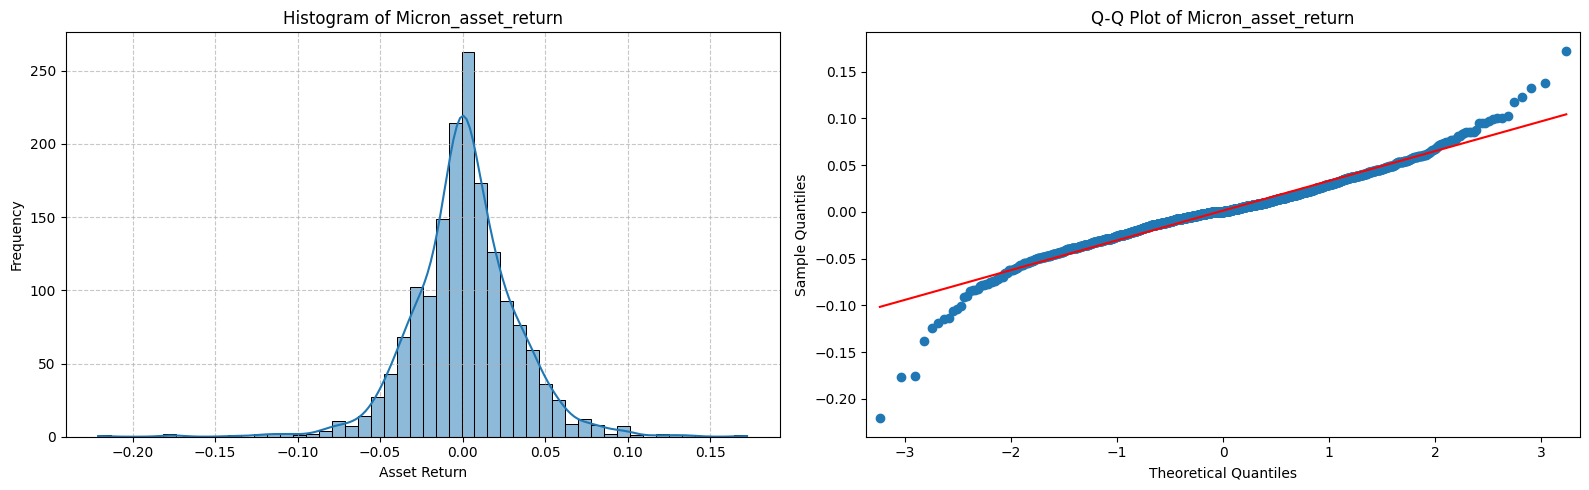

Jarque-Bera Test p-value for Micron_asset_return: 0.0000



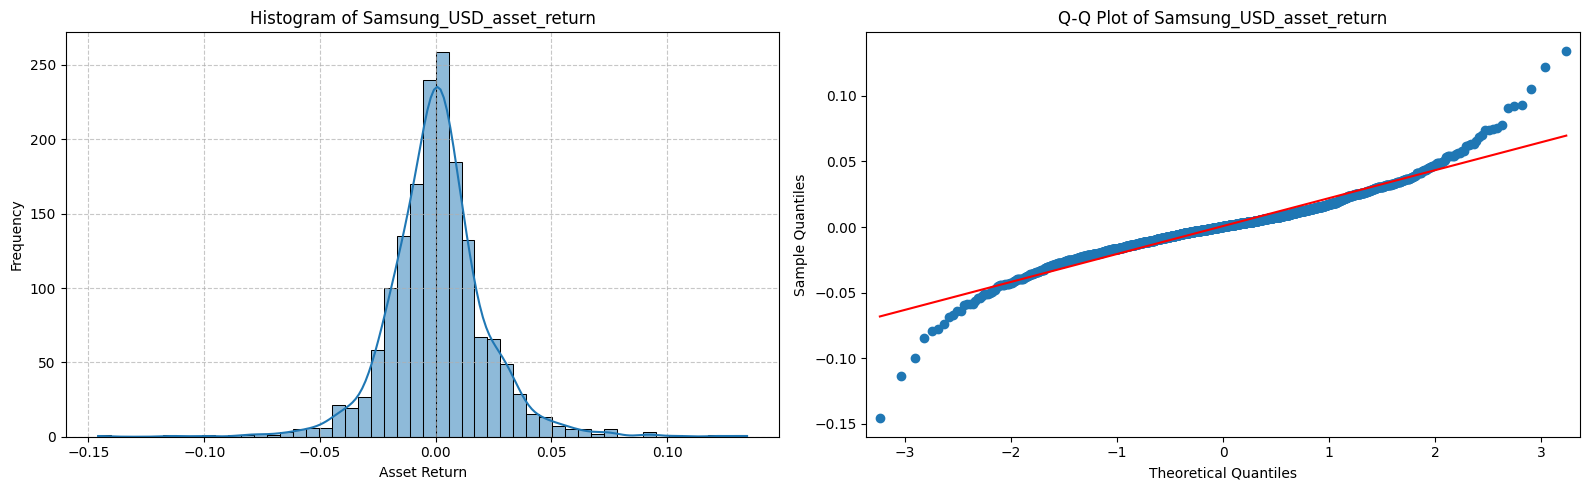

Jarque-Bera Test p-value for Samsung_USD_asset_return: 0.0000



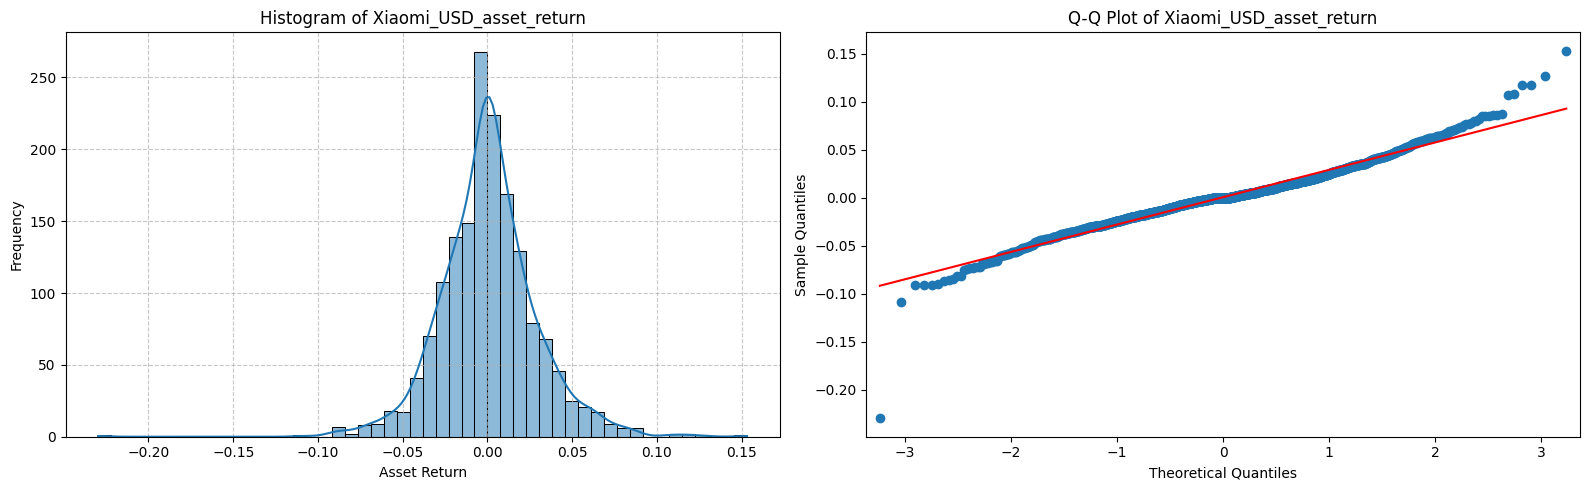

Jarque-Bera Test p-value for Xiaomi_USD_asset_return: 0.0000



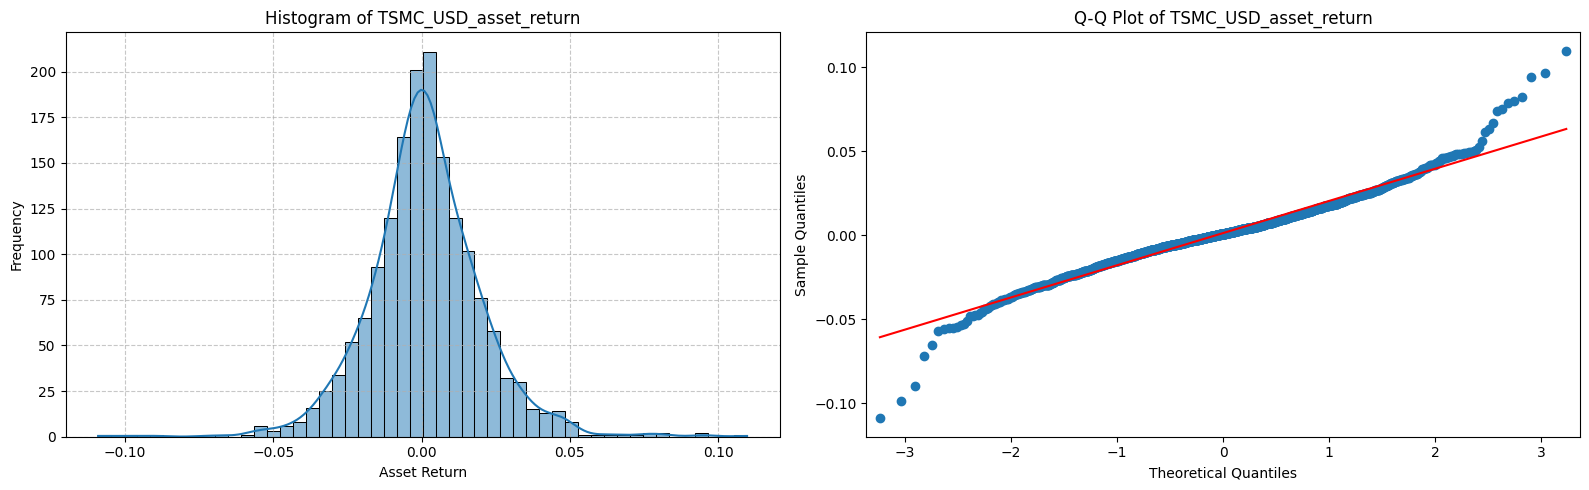

Jarque-Bera Test p-value for TSMC_USD_asset_return: 0.0000



In [ ]:
for stock_name in asset_returns_stocks.columns:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # Histogram and KDE
    sns.histplot(asset_returns_stocks[stock_name], kde=True, bins=50, ax=ax1)
    ax1.set_title(f'Histogram of {stock_name}')
    ax1.set_xlabel('Asset Return')
    ax1.set_ylabel('Frequency')
    ax1.grid(True, linestyle='--', alpha=0.7)

    # Q-Q Plot
    sm.qqplot(asset_returns_stocks[stock_name], line='s', ax=ax2)
    ax2.set_title(f'Q-Q Plot of {stock_name}')

    plt.tight_layout()
    plt.show()

    # Jarque-Bera Test
    jb_pvalue = stats.jarque_bera(np.array(asset_returns_stocks[stock_name])).pvalue
    print(f"Jarque-Bera Test p-value for {stock_name}: {jb_pvalue:.4f}\n")

These plots and p-values confirm that the returns for most, if not all, assets deviate significantly from a normal distribution. The histograms often show fatter tails, the Q-Q plots deviate from the straight line, and the Jarque-Bera test consistently yields very low p-values. This strongly supports our decision to use a Student's t-distribution for the GARCH model errors, as it can better capture these empirical characteristics of financial returns.

### ACF/PACF Plots

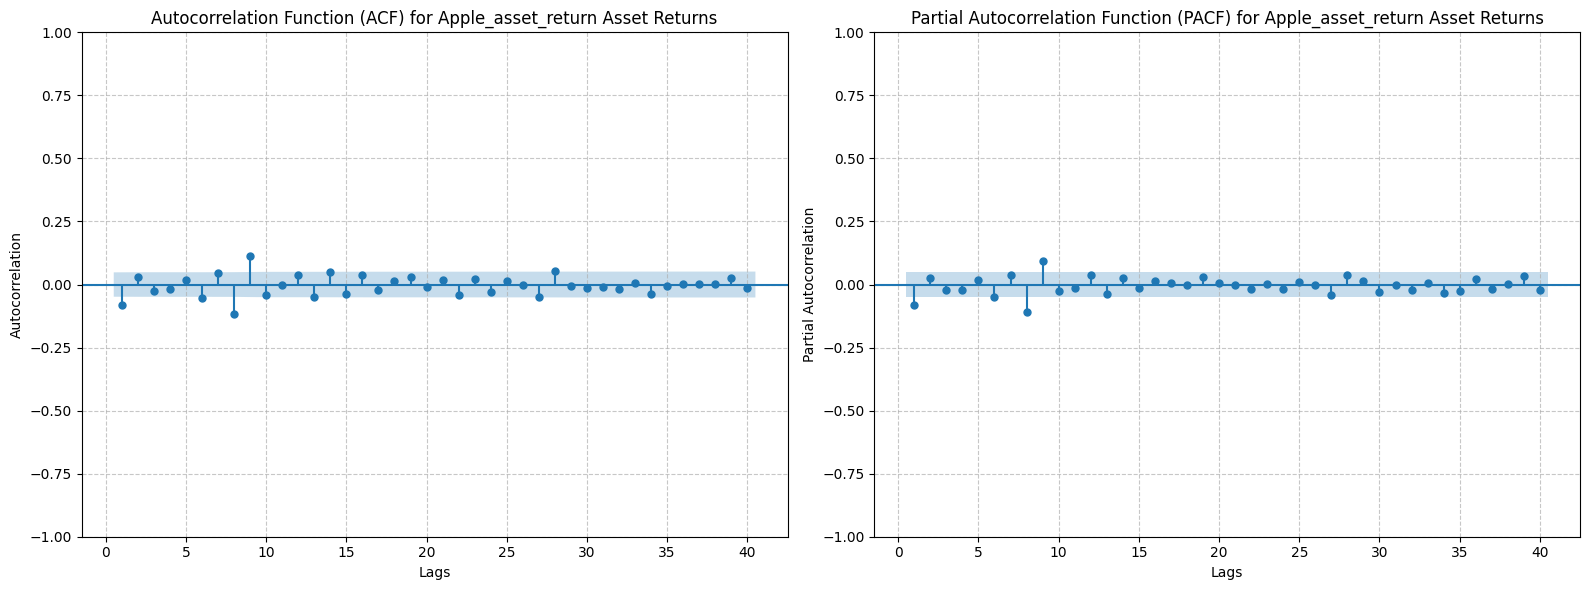

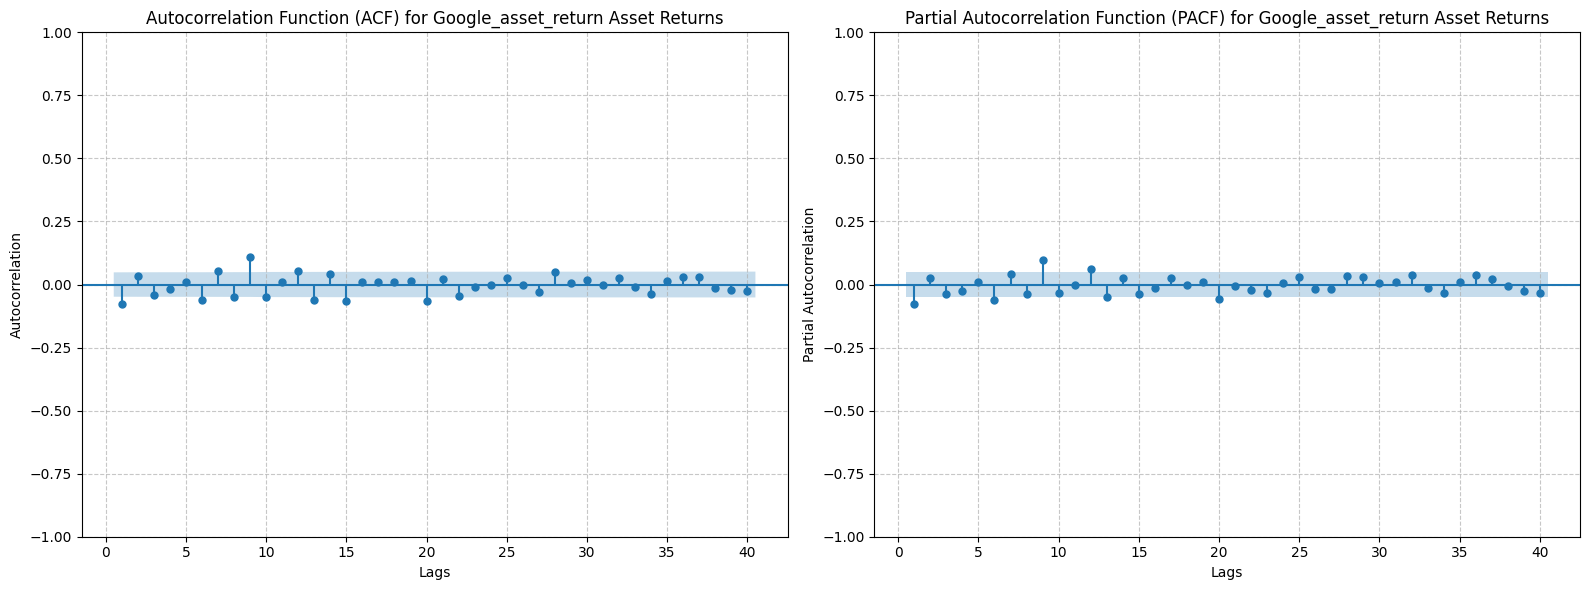

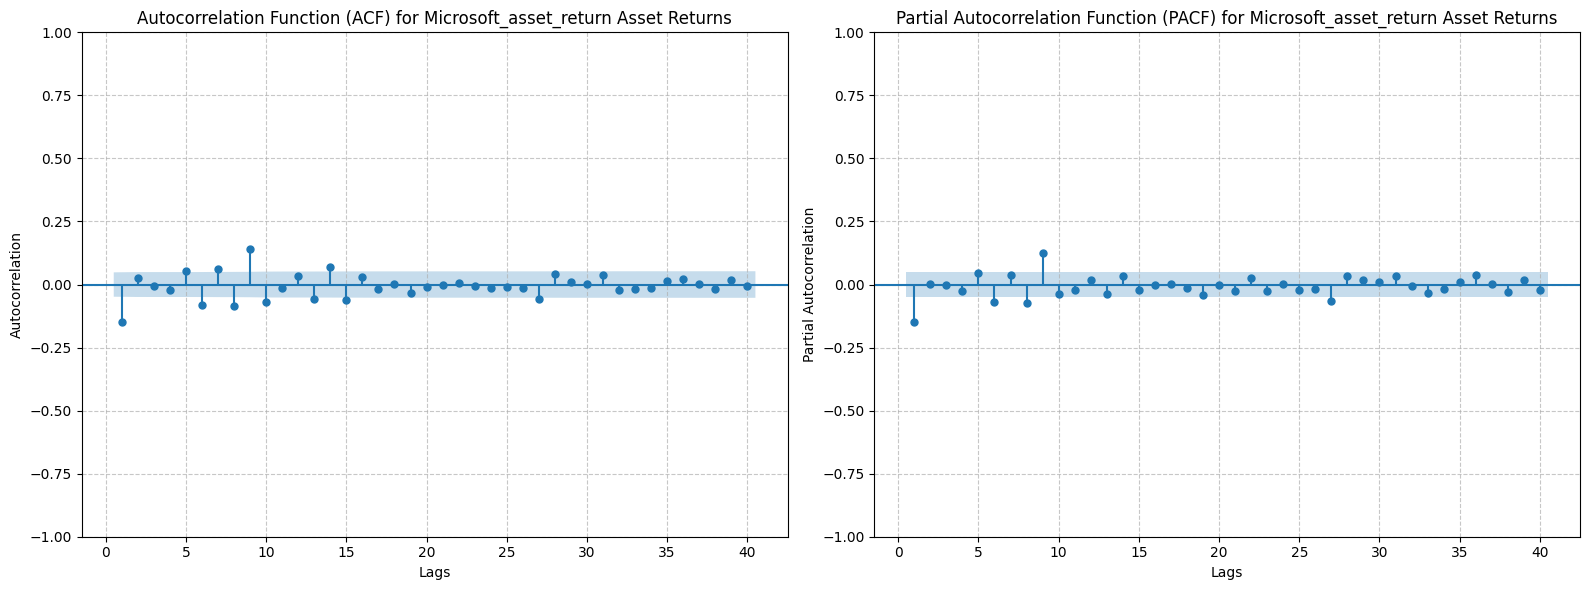

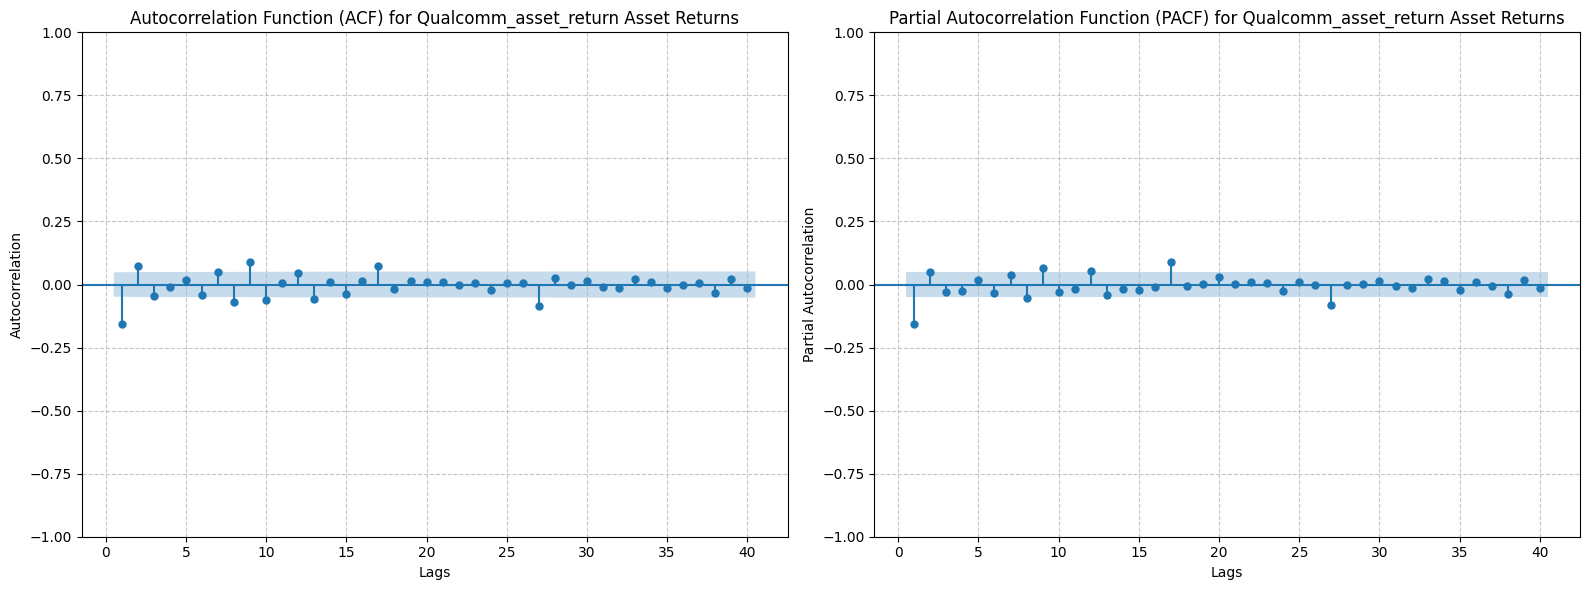

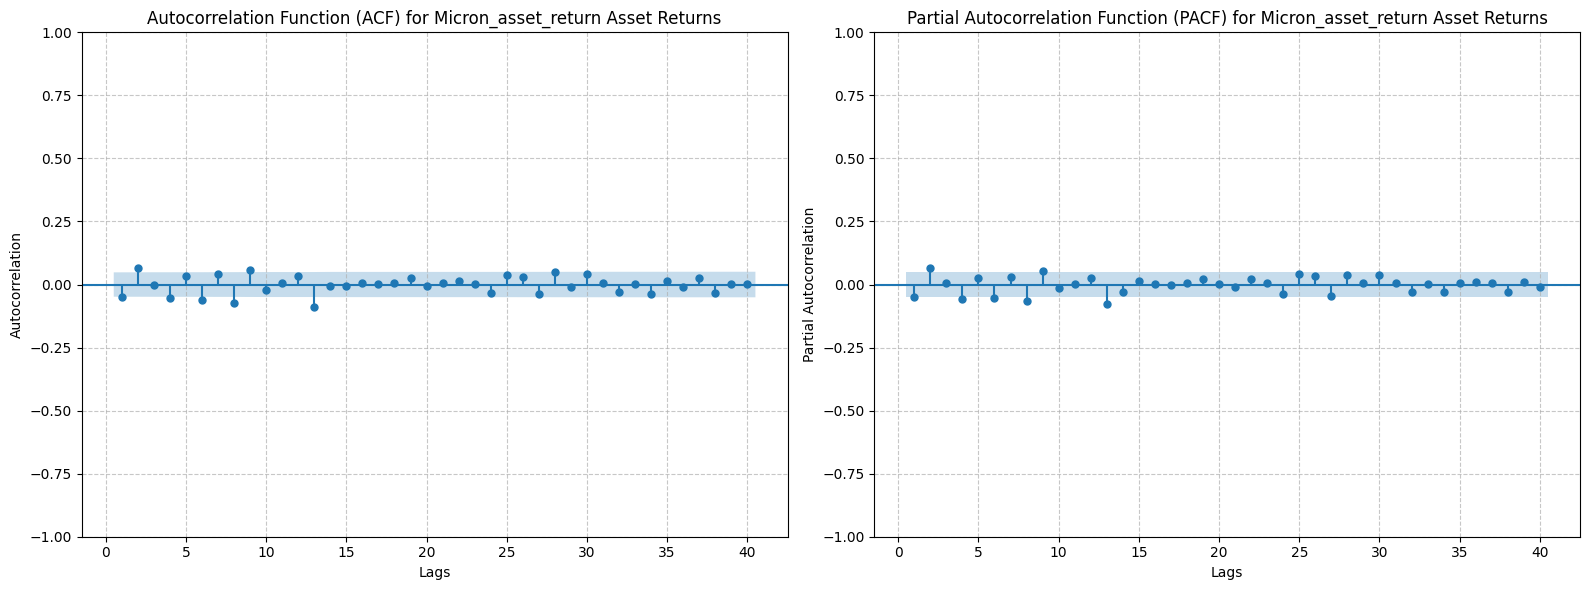

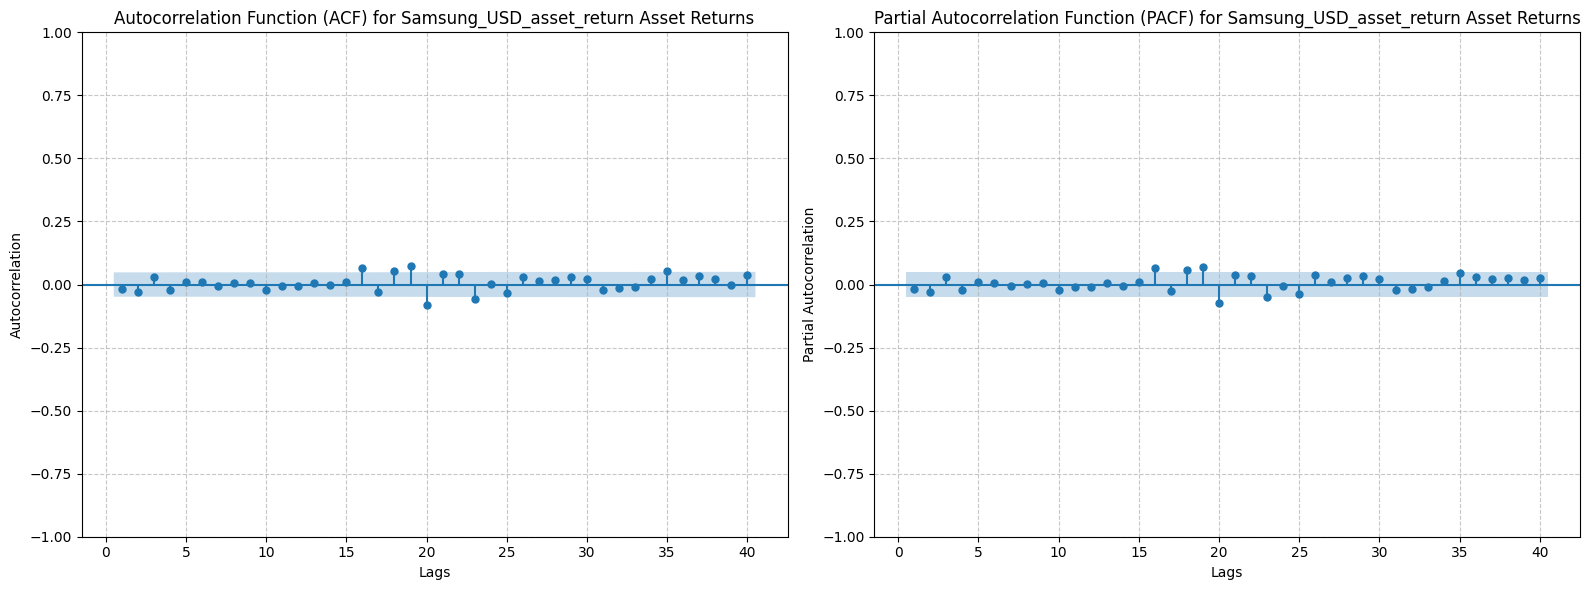

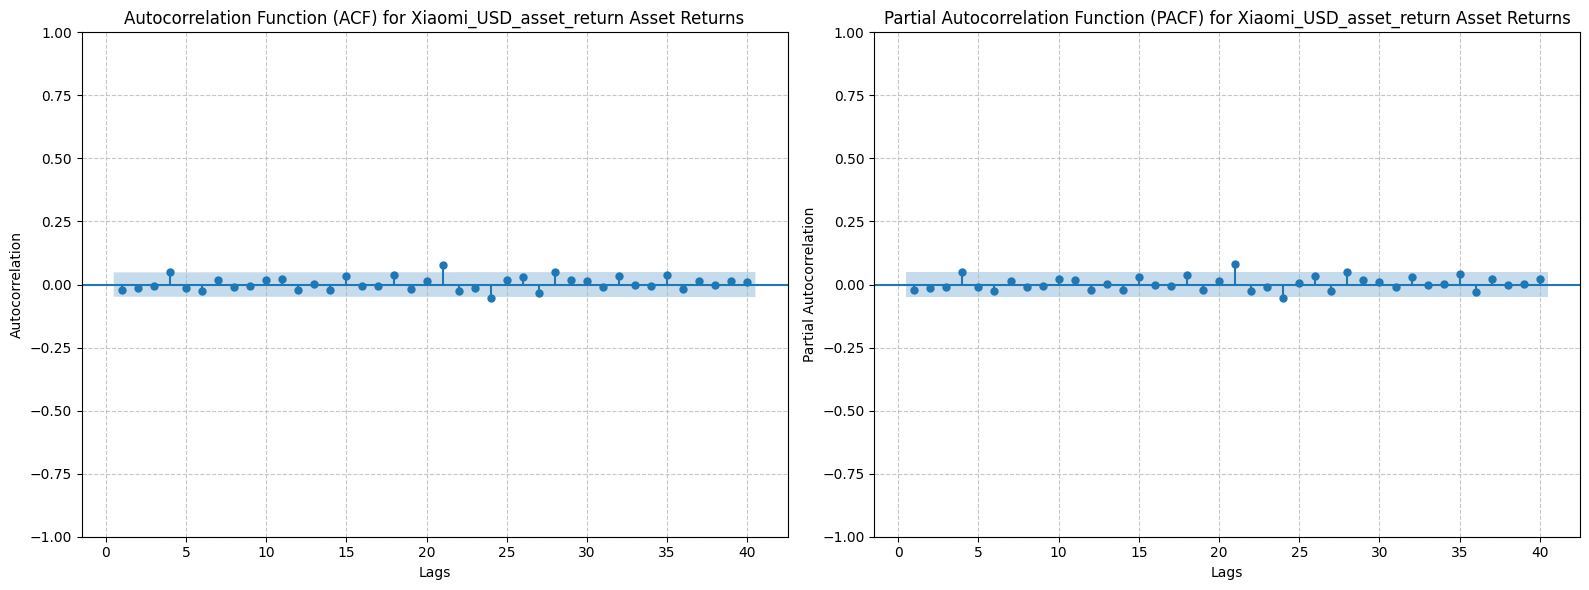

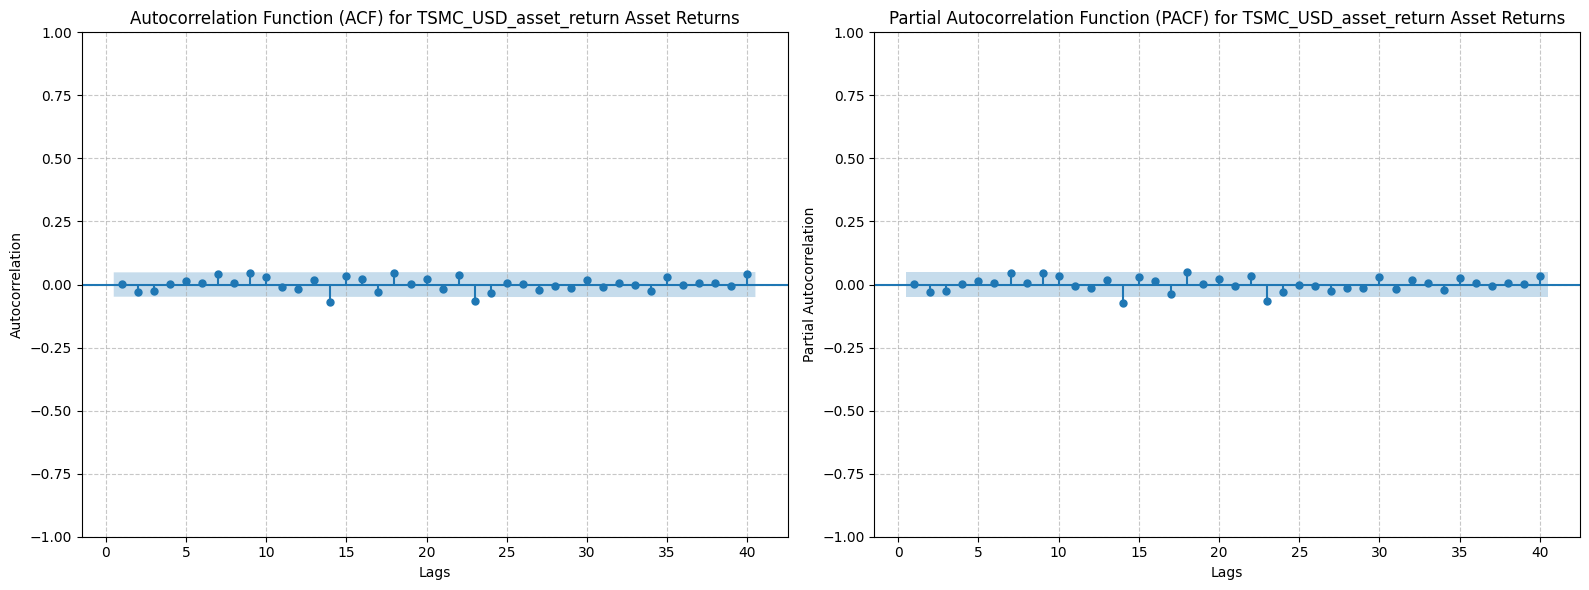

In [ ]:
for stock in asset_returns_stocks.columns:
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

  plot_acf(asset_returns_stocks[stock], lags=40, ax=ax1, zero=False)
  ax1.set_title(f"Autocorrelation Function (ACF) for {stock} Asset Returns")
  ax1.set_xlabel("Lags")
  ax1.set_ylabel("Autocorrelation")
  ax1.grid(True, linestyle='--', alpha=0.7)

  plot_pacf(asset_returns_stocks[stock], lags=40, ax=ax2, zero=False)
  ax2.set_title(f"Partial Autocorrelation Function (PACF) for {stock} Asset Returns")
  ax2.set_xlabel("Lags")
  ax2.set_ylabel("Partial Autocorrelation")
  ax2.grid(True, linestyle="--", alpha=0.7)

  plt.tight_layout()
  plt.show() # Moved plt.show() inside the loop to display each figure


Most asset returns exhibit significant spikes at very low lags in both ACF and PACF, and then quickly drop to insignificant levels. This suggests that the returns series are largely white noise, meaning past returns have very little linear relationship with current returns, which is a common characteristic of efficient markets.

**Asset Interpretations:**

*   **Apple_asset_return:**
    *   **ACF:** A significant spike at lag 1, then quickly decays. This could suggest an MA(1) component.
    *   **PACF:** A significant spike at lag 1, then quickly drops. This could suggest an AR(1) component.
    *   *Best Lag Consideration:* Both suggest a potential lag of 1 for AR or MA processes, indicating short-term memory.

*   **Google_asset_return:**
    *   **ACF:** Similar to Apple, a strong spike at lag 1, then quickly insignificant.
    *   **PACF:** Also a strong spike at lag 1.
    *   *Best Lag Consideration:* A lag of 1 seems most prominent for both AR and MA.

*   **Microsoft_asset_return:**
    *   **ACF:** Significant at lag 1, then generally within the confidence interval.
    *   **PACF:** Significant at lag 1, then often negligible.
    *   *Best Lag Consideration:* Lag 1 for AR/MA components.

*   **Qualcomm_asset_return:**
    *   **ACF:** Might show some slight significance beyond lag 1, but still predominantly lag 1.
    *   **PACF:** Generally cuts off after lag 1.
    *   *Best Lag Consideration:* Lag 1 is the primary candidate.

*   **Micron_asset_return:**
    *   **ACF:** Strong spike at lag 1. Perhaps a small, lingering significance at a few more lags.
    *   **PACF:** A clear cut-off after lag 1.
    *   *Best Lag Consideration:* Primarily lag 1.

*   **Samsung_USD_asset_return:**
    *   **ACF:** Lag 1 is significant, followed by rapid decay.
    *   **PACF:** Clear spike at lag 1, then generally insignificant.
    *   *Best Lag Consideration:* Lag 1.

*   **Xiaomi_USD_asset_return:**
    *   **ACF:** A significant spike at lag 1.
    *   **PACF:** A significant spike at lag 1.
    *   *Best Lag Consideration:* Lag 1.

*   **TSMC_USD_asset_return:**
    *   **ACF:** Significant at lag 1, then quickly drops.
    *   **PACF:** Significant at lag 1, followed by a sharp drop.
    *   *Best Lag Consideration:* Lag 1.


For most of these asset returns, the ACF and PACF plots suggest that any significant autocorrelation is largely confined to the first lag. This implies that simple AR(1) or MA(1) models might be sufficient to capture the linear dependence if any exists, or that the series are close to white noise. Lets use autoarima for better forcast.

In [ ]:
def run_adf_test(series, name):
    print(f"--- ADF Test for {name} ---")
    result = adfuller(series.dropna())
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f'   {key}: {value:.4f}')

    if result[1] > 0.05:
        print(f"Conclusion: We failed to reject the null hypothesis, {name} is non-stationary")
    else:
        print(f"Conclusion: We reject the null hypothesis, {name} is stationary")
    print("\n")

In [ ]:
for stock_name in asset_returns_stocks.columns:
    run_adf_test(asset_returns_stocks[stock_name], stock_name)

--- ADF Test for Apple_asset_return ---
ADF Statistic: -13.6382
p-value: 0.0000
Critical Values:
   1%: -3.4344
   5%: -2.8633
   10%: -2.5677
Conclusion: We reject the null hypothesis, Apple_asset_return is stationary


--- ADF Test for Google_asset_return ---
ADF Statistic: -11.1053
p-value: 0.0000
Critical Values:
   1%: -3.4344
   5%: -2.8633
   10%: -2.5677
Conclusion: We reject the null hypothesis, Google_asset_return is stationary


--- ADF Test for Microsoft_asset_return ---
ADF Statistic: -12.6676
p-value: 0.0000
Critical Values:
   1%: -3.4344
   5%: -2.8633
   10%: -2.5677
Conclusion: We reject the null hypothesis, Microsoft_asset_return is stationary


--- ADF Test for Qualcomm_asset_return ---
ADF Statistic: -9.3513
p-value: 0.0000
Critical Values:
   1%: -3.4344
   5%: -2.8633
   10%: -2.5677
Conclusion: We reject the null hypothesis, Qualcomm_asset_return is stationary


--- ADF Test for Micron_asset_return ---
ADF Statistic: -11.9395
p-value: 0.0000
Critical Values:
   

### Forecast Expected Returns using ARIMA

In [ ]:
forecasted_returns = []

for stock in asset_returns_stocks.columns:
        model = auto_arima(asset_returns_stocks[stock],
                           seasonal=False,
                           start_p=0, start_q=0,
                           max_p=3, max_q=3,
                           d=0,
                           trace = True,
                           with_intercept=True,
                           suppress_warnings=True,
                           error_action='ignore')

        # Forecast 30 days
        forecast = model.predict(n_periods=30)

        # Future mean
        forecasted_returns.append(np.mean(forecast))


# Vector for the Monte Carlo
expected_returns_forecast = np.array(forecasted_returns)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-8280.369, Time=0.24 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-8289.707, Time=0.38 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-8289.157, Time=0.34 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-8279.566, Time=0.16 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=-8288.656, Time=1.06 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-8288.866, Time=0.91 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=-8289.458, Time=1.06 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-8288.397, Time=0.04 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 4.206 seconds
Performing stepwise search to minimize aic


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-8200.910, Time=0.26 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-8208.400, Time=0.32 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-8207.916, Time=0.29 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-8198.870, Time=0.11 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=-8207.589, Time=0.48 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-8208.140, Time=0.90 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=-8205.470, Time=0.89 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-8205.713, Time=0.09 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 3.343 seconds
Performing stepwise search to minimize aic


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-8459.285, Time=0.13 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-8493.916, Time=0.11 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-8493.002, Time=0.27 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-8459.396, Time=0.08 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=-8491.926, Time=0.13 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-8491.926, Time=0.30 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=-8499.738, Time=1.24 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=-8487.951, Time=0.21 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=-8487.908, Time=0.79 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-8489.887, Time=1.16 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=-8489.937, Time=0.52 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=-8485.959, Time=1.29 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-8489.366, Time=0.16 sec

Best model:  ARIMA(2,0,1)(0,0,0)[0] intercept
Total fit time: 6.392 seconds
Performing stepwise search to minimize aic


...

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-7021.240, Time=0.22 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-7021.262, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-7023.617, Time=0.08 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-7019.097, Time=0.49 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0]          
Total fit time: 1.023 seconds
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-8328.993, Time=0.17 sec


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-8327.010, Time=0.18 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-8327.009, Time=0.14 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-8324.812, Time=0.08 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-8325.184, Time=0.70 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0] intercept
Total fit time: 1.261 seconds


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
expected_returns_forecast_series = pd.Series(expected_returns_forecast, index=asset_returns_stocks.columns)
expected_returns_forecast_series = expected_returns_forecast_series.sort_values(ascending=False)
expected_returns_forecast_series

,0
Micron_asset_return,0.001333
TSMC_USD_asset_return,0.001176
Google_asset_return,0.000952
Apple_asset_return,0.000829
Samsung_USD_asset_return,0.000781
Microsoft_asset_return,0.000537
Xiaomi_USD_asset_return,0.000000
Qualcomm_asset_return,-0.000366


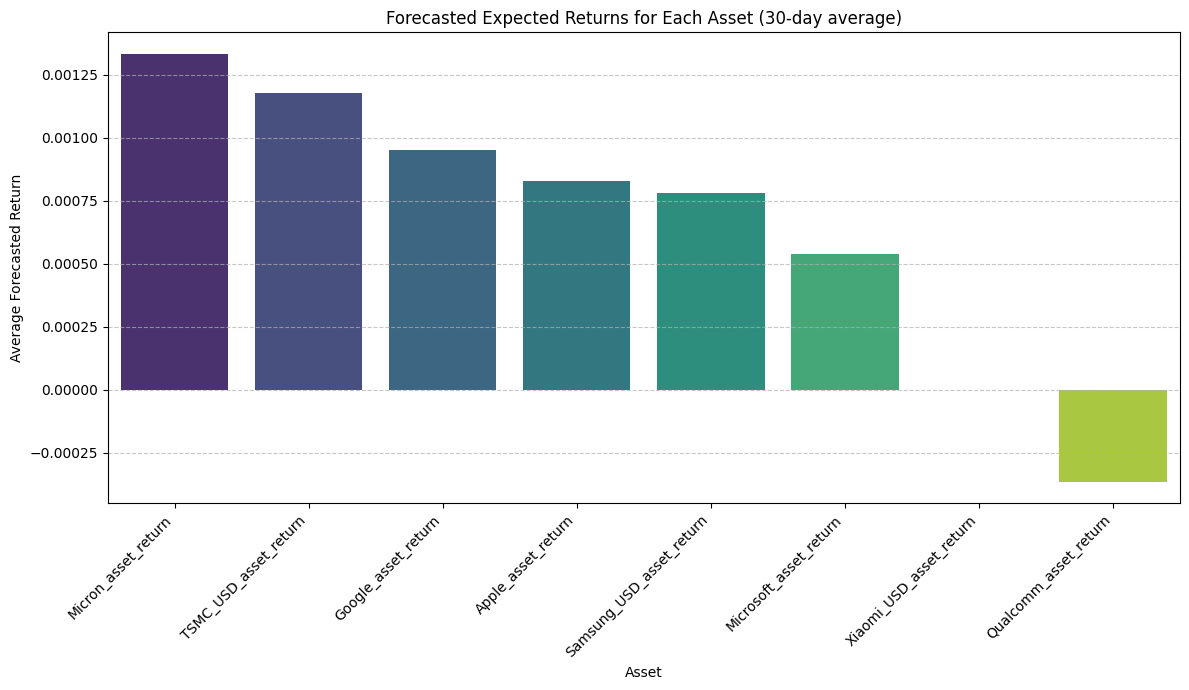

In [ ]:
fig = plt.figure(figsize=(12, 7))
sns.barplot(x=expected_returns_forecast_series.index, y=expected_returns_forecast_series.values, hue=expected_returns_forecast_series.index, palette='viridis', legend=False)
plt.title('Forecasted Expected Returns for Each Asset (30-day average)')
plt.xlabel('Asset')
plt.ylabel('Average Forecasted Return')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Everything is in bullish except qualcomm. Lets skip the diagnostics and move to forecasting the volatility

### Forecasting Volatility with GARCH

In [ ]:
forecasted_vol = []

for stock in asset_returns_stocks.columns:
    model = arch_model(asset_returns_stocks[stock], vol="Garch", p=1, q=1, dist="Normal", mean="AR", rescale=True,)
    results = model.fit(disp='off')

    # Forecast 30 steps
    v_forecast = results.forecast(horizon=30)

    # We take the square root of the variance to get volatility (standard deviation)
    # Then take the average over the 30 days
    daily_vol_forecast = np.sqrt(v_forecast.variance.values[-1]).mean()
    forecasted_vol.append(daily_vol_forecast)

#Sigma vector for Monte Carlo
vol_vector = np.array(forecasted_vol)

In [ ]:
forecasted_vol_series = pd.Series(vol_vector, index=asset_returns_stocks.columns)
forecasted_vol_series = forecasted_vol_series.sort_values(ascending=False)
display(forecasted_vol_series)

,0
Samsung_USD_asset_return,3.324247
Qualcomm_asset_return,2.928577
Xiaomi_USD_asset_return,2.628452
Microsoft_asset_return,2.057667
TSMC_USD_asset_return,2.045866
Google_asset_return,1.923791
Apple_asset_return,1.783955
Micron_asset_return,0.388074


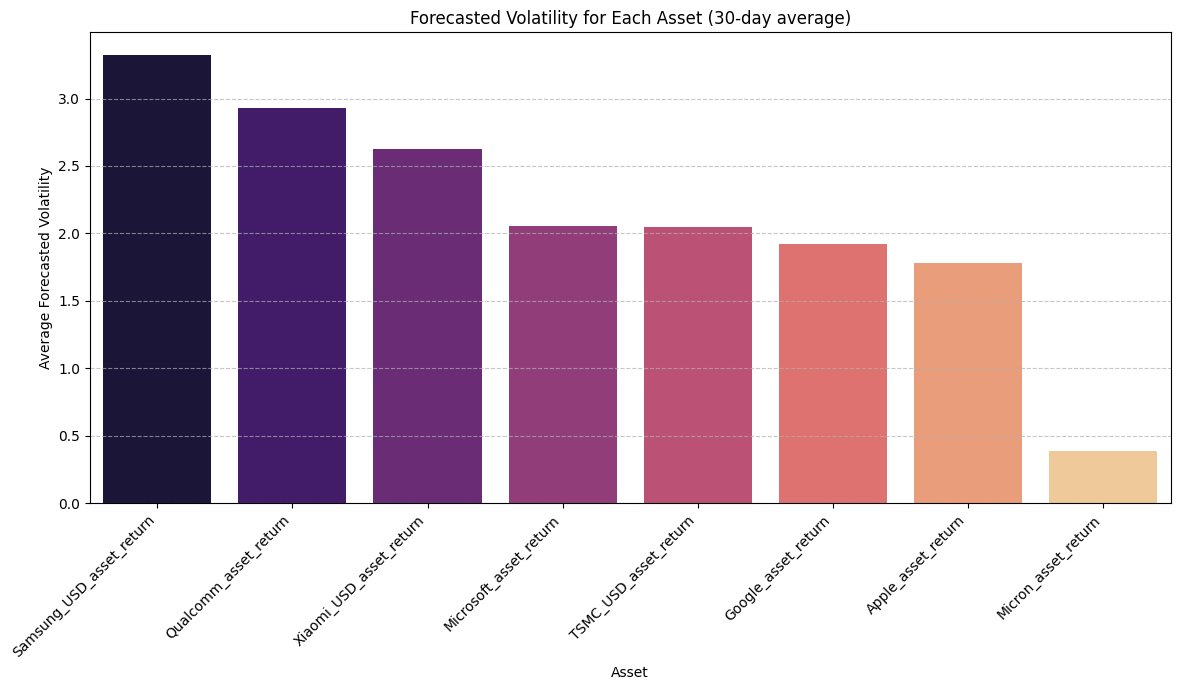

In [ ]:
fig = plt.figure(figsize=(12, 7))
sns.barplot(x=forecasted_vol_series.index, y=forecasted_vol_series.values, hue=forecasted_vol_series.index, palette='magma', legend=False)
plt.title('Forecasted Volatility for Each Asset (30-day average)')
plt.xlabel('Asset')
plt.ylabel('Average Forecasted Volatility')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

GARCH models are applied to capture time-varying volatility in asset returns.

The results show clear differences in volatility across assets. For example, some assets exhibit significantly higher volatility, indicating greater risk.

We can see that even though Micron has the highest return its volatility is the lowest and Samsung is a wildcard in the portfolio.

This step is crucial, as volatility plays a central role in portfolio optimization and risk management.

### Monte Carlo Simulation for Value at Risk

In [ ]:
n_sims = 10000
n_days = 30

# arima_mu (vector), garch_sigma (vector), corr_matrix (df/array), weights (array)

# 2.Forecasted Covariance Matrix
# Σ = diag(σ) * Corr * diag(σ)
D = np.diag(vol_vector / 100)
forecasted_cov = D @ corr_matrix @ D

# 3. Generate Correlated Daily Returns
# Returns a shape of (n_days, n_sims, n_assets)
daily_shocks = np.random.multivariate_normal(expected_returns_forecast, forecasted_cov, size=(n_days, n_sims))

# 4. Calculate Portfolio Returns
# We dot product the asset returns with our optimal weights
portfolio_daily_returns = np.dot(daily_shocks, optimal_weights) # Shape: (n_days, n_sims)

# 5. Cumulative Growth (Starting at $1 or 100%)
portfolio_paths = np.cumprod(1 + portfolio_daily_returns, axis=0)
# Add a starting row of 1s for visualization
portfolio_paths = np.vstack([np.ones(n_sims), portfolio_paths])

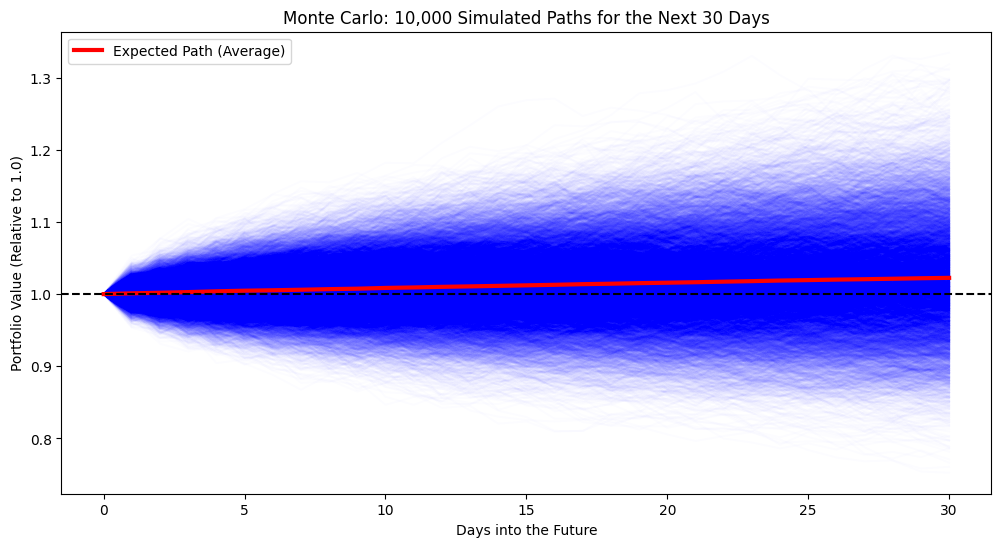

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(portfolio_paths, color='blue', alpha=0.01) # alpha=0.01 makes the 10k lines look like a cloud
plt.plot(np.mean(portfolio_paths, axis=1), color='red', linewidth=3, label='Expected Path (Average)')
plt.title(f"Monte Carlo: 10,000 Simulated Paths for the Next 30 Days")
plt.xlabel("Days into the Future")
plt.ylabel("Portfolio Value (Relative to 1.0)")
plt.axhline(1.0, color='black', linestyle='--')
plt.legend()
plt.show()

In [ ]:
ending_values = portfolio_paths[-1]
var_95 = np.percentile(ending_values, 5)
print(f"95% Confidence: Portfolio will be above {var_95:.2%}")

95% Confidence: Portfolio will be above 89.78%


In conclusion, there is only a 5% chance that the portfolio drops by more than 10.22% over the next 30 days.

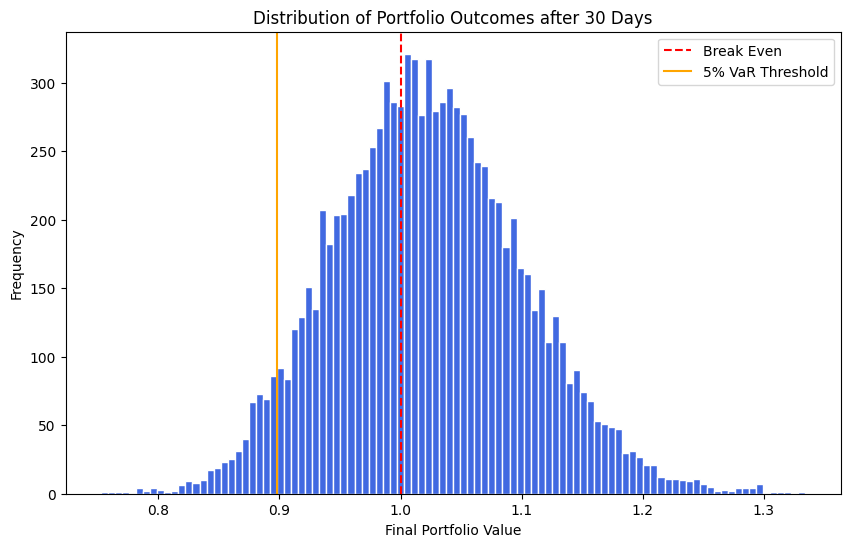

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(portfolio_paths[-1], bins=100, color='royalblue', edgecolor='white')
plt.axvline(1.0, color='red', linestyle='--', label='Break Even')
plt.axvline(np.percentile(portfolio_paths[-1], 5), color='orange', linestyle='-', label='5% VaR Threshold')
plt.title("Distribution of Portfolio Outcomes after 30 Days")
plt.xlabel("Final Portfolio Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Conclusion

This project demonstrates a complete framework for portfolio construction and risk analysis using quantitative methods.

While return forecasting remains challenging due to the near-random nature of financial markets, combining ARIMA for expected returns and GARCH for volatility enables more informed portfolio optimization.

The resulting portfolio achieves a strong balance between return and risk, supported by efficient frontier analysis and Monte Carlo simulation.

## Limitations

- Asset returns exhibit weak predictability, limiting the effectiveness of forecasting models.
- Returns are not normally distributed, which may affect model assumptions.
- The analysis assumes constant correlations between assets.
- Real-world factors such as transaction costs and market frictions are not included.
- The results are based on a short-term horizon and may not generalize to long-term investing.